In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv('/content/Telco-Customer-Churn.csv')

print("Dataset cargado correctamente")
print("Número de registros:", len(df))
print("Número de variables:", len(df.columns))


Dataset cargado correctamente
Número de registros: 7043
Número de variables: 21


In [2]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
# Mostrar los nombres de las variables
print("Variables del dataset:\n")

for i, columna in enumerate(df.columns, start=1):
    print(i, "-", columna)

Variables del dataset:

1 - customerID
2 - gender
3 - SeniorCitizen
4 - Partner
5 - Dependents
6 - tenure
7 - PhoneService
8 - MultipleLines
9 - InternetService
10 - OnlineSecurity
11 - OnlineBackup
12 - DeviceProtection
13 - TechSupport
14 - StreamingTV
15 - StreamingMovies
16 - Contract
17 - PaperlessBilling
18 - PaymentMethod
19 - MonthlyCharges
20 - TotalCharges
21 - Churn


Conocemos la estructura del dataset

In [7]:
# Información general del dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


Estadísticas descriptivas

estadísticas descriptivas básicas

In [8]:
# Estadísticas descriptivas de las variables numéricas
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Valores nulos

In [9]:
# Cantidad y porcentaje de valores nulos por variable

nulos = df.isnull().sum()
porcentaje_nulos = (df.isnull().sum() / len(df)) * 100

tabla_nulos = pd.DataFrame({
    'Valores nulos': nulos,
    'Porcentaje (%)': porcentaje_nulos.round(2)
})

tabla_nulos

,Valores nulos,Porcentaje (%)
customerID,0,0.0
gender,0,0.0
SeniorCitizen,0,0.0
Partner,0,0.0
Dependents,0,0.0
tenure,0,0.0
PhoneService,0,0.0
MultipleLines,0,0.0
InternetService,0,0.0
OnlineSecurity,0,0.0


Registros duplicados

Reportar la cantidad y el porcentaje de registros duplicados.

In [10]:
# Cantidad y porcentaje de registros duplicados

cantidad_duplicados = df.duplicated().sum()

porcentaje_duplicados = (
    cantidad_duplicados / len(df)
) * 100

print("Cantidad de registros duplicados:", cantidad_duplicados)
print("Porcentaje de registros duplicados:", round(porcentaje_duplicados, 2), "%")

Cantidad de registros duplicados: 0
Porcentaje de registros duplicados: 0.0 %


Revisar la variable objetivo

In [11]:
# Distribución de la variable objetivo Churn

print(df['Churn'].value_counts())

print("\nPorcentajes:")
print((df['Churn'].value_counts(normalize=True) * 100).round(2))

Churn
No     5174
Yes    1869
Name: count, dtype: int64

Porcentajes:
Churn
No     73.46
Yes    26.54
Name: proportion, dtype: float64


In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

print("Librerías para gráficos cargadas correctamente")

Librerías para gráficos cargadas correctamente


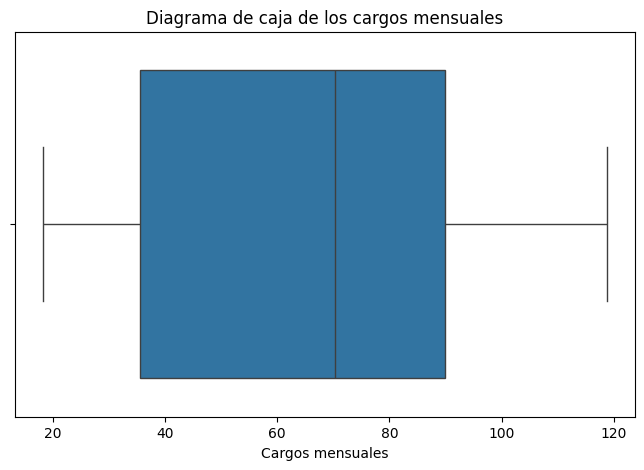

In [15]:
# Identificación visual de valores atípicos en MonthlyCharges

plt.figure(figsize=(8, 5))

sns.boxplot(x=df['MonthlyCharges'])

plt.title('Diagrama de caja de los cargos mensuales')
plt.xlabel('Cargos mensuales')

plt.show()

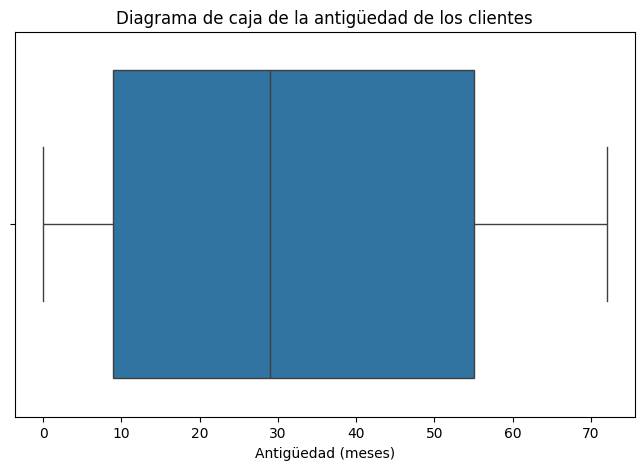

In [16]:
# Identificación visual de valores atípicos en tenure

plt.figure(figsize=(8, 5))

sns.boxplot(x=df['tenure'])

plt.title('Diagrama de caja de la antigüedad de los clientes')
plt.xlabel('Antigüedad (meses)')

plt.show()

In [17]:
# Cálculo de valores atípicos mediante el método IQR

Q1 = df['MonthlyCharges'].quantile(0.25)
Q3 = df['MonthlyCharges'].quantile(0.75)

IQR = Q3 - Q1

limite_inferior = Q1 - 1.5 * IQR
limite_superior = Q3 + 1.5 * IQR

atipicos = df[
    (df['MonthlyCharges'] < limite_inferior) |
    (df['MonthlyCharges'] > limite_superior)
]

print("Q1:", Q1)
print("Q3:", Q3)
print("IQR:", IQR)
print("Límite inferior:", limite_inferior)
print("Límite superior:", limite_superior)
print("Cantidad de valores atípicos:", len(atipicos))
print(
    "Porcentaje de valores atípicos:",
    round((len(atipicos) / len(df)) * 100, 2),
    "%"
)

Q1: 35.5
Q3: 89.85
IQR: 54.349999999999994
Límite inferior: -46.02499999999999
Límite superior: 171.375
Cantidad de valores atípicos: 0
Porcentaje de valores atípicos: 0.0 %


Gráfico de distribución de Churn

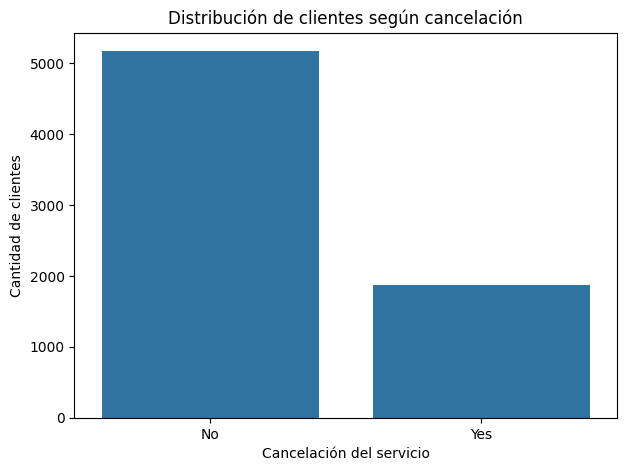

In [19]:
plt.figure(figsize=(7, 5))

sns.countplot(data=df, x='Churn')

plt.title('Distribución de clientes según cancelación')
plt.xlabel('Cancelación del servicio')
plt.ylabel('Cantidad de clientes')

plt.show()

Distribución de los cargos mensuales

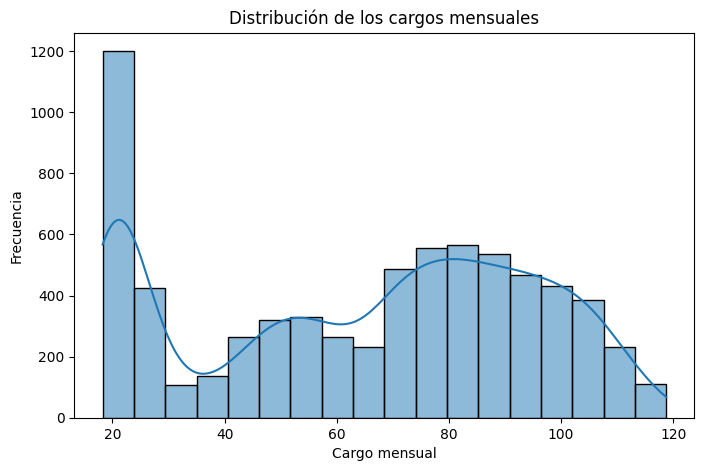

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(data=df, x='MonthlyCharges', kde=True)

plt.title('Distribución de los cargos mensuales')
plt.xlabel('Cargo mensual')
plt.ylabel('Frecuencia')

plt.show()

Cancelación según tipo de contrato

Ahora vamos a analizar si existe alguna diferencia en la cancelación de clientes según el tipo de contrato.

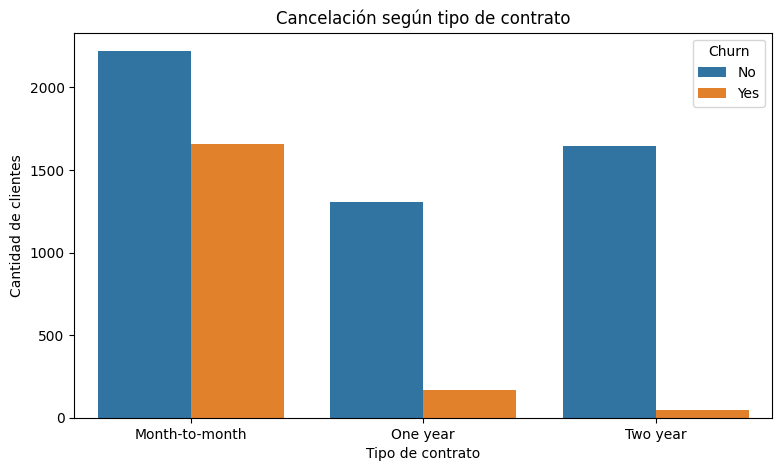

In [21]:
plt.figure(figsize=(9, 5))

sns.countplot(data=df, x='Contract', hue='Churn')

plt.title('Cancelación según tipo de contrato')
plt.xlabel('Tipo de contrato')
plt.ylabel('Cantidad de clientes')

plt.show()

Antigüedad vs. cargos mensuales.
 Este gráfico nos permitirá observar la relación entre la antigüedad del cliente (tenure) y sus cargos mensuales (MonthlyCharges), diferenciando además si el cliente canceló o permaneció.

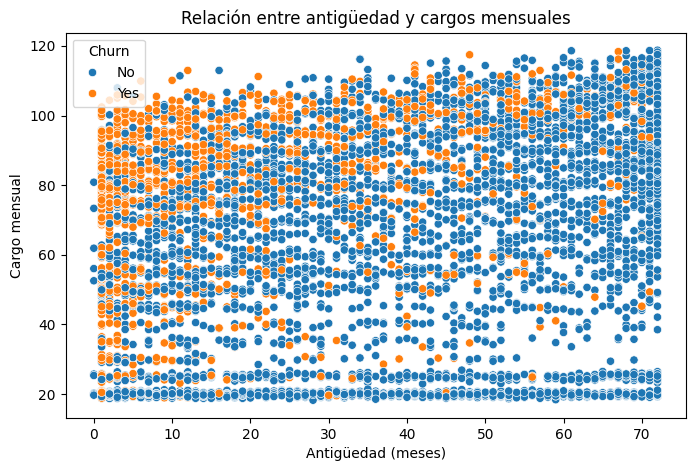

In [22]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x='tenure',
    y='MonthlyCharges',
    hue='Churn'
)

plt.title('Relación entre antigüedad y cargos mensuales')
plt.xlabel('Antigüedad (meses)')
plt.ylabel('Cargo mensual')

plt.show()

Primero vamos a revisar exactamente qué problemas de calidad tienen nuestros datos.

In [23]:
# Revisión de valores nulos

print("Valores nulos por variable:")
print(df.isnull().sum())

Valores nulos por variable:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


Registros duplicados antes del preprocesamiento.

In [24]:
# Revisión de registros duplicados

print("Cantidad de registros duplicados:", df.duplicated().sum())

Cantidad de registros duplicados: 0


In [25]:
# Revisar posibles valores vacíos en TotalCharges

espacios_totalcharges = df['TotalCharges'].astype(str).str.strip().eq('').sum()

print("Valores vacíos en TotalCharges:", espacios_totalcharges)

Valores vacíos en TotalCharges: 11


In [26]:
# Convertir TotalCharges a formato numérico
# Los valores vacíos se convertirán automáticamente en NaN

df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

print("Conversión de TotalCharges realizada correctamente")
print("Valores nulos después de la conversión:",
      df['TotalCharges'].isnull().sum())

Conversión de TotalCharges realizada correctamente
Valores nulos después de la conversión: 11


In [27]:
# Revisar los registros que presentan TotalCharges vacío

df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,...,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,...,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,...,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Calcular el porcentaje

In [28]:
# Calcular porcentaje de valores faltantes en TotalCharges

cantidad_nulos = df['TotalCharges'].isnull().sum()
porcentaje_nulos = (cantidad_nulos / len(df)) * 100

print("Cantidad de valores faltantes:", cantidad_nulos)
print("Porcentaje de valores faltantes:",
      round(porcentaje_nulos, 2), "%")

Cantidad de valores faltantes: 11
Porcentaje de valores faltantes: 0.16 %


Ahora sí vamos a realizar la limpieza.

In [29]:
# Eliminar registros con valores faltantes en TotalCharges

registros_antes = len(df)

df = df.dropna(subset=['TotalCharges'])

registros_despues = len(df)

print("Registros antes de la limpieza:", registros_antes)
print("Registros eliminados:", registros_antes - registros_despues)
print("Registros después de la limpieza:", registros_despues)

Registros antes de la limpieza: 7043
Registros eliminados: 11
Registros después de la limpieza: 7032


comprobamos si la eliminación funcionó

In [30]:
# Verificar valores nulos después de la limpieza

print("Valores nulos después del tratamiento:")
print(df.isnull().sum())

Valores nulos después del tratamiento:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [31]:
nulos = df.isnull().sum()

print(nulos[nulos > 0])

Series([], dtype: int64)


In [34]:
df.dtypes

,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


Revisamos las variables categóricas

In [35]:
variables_categoricas = df.select_dtypes(include=['object']).columns

print("Variables categóricas:")
print(list(variables_categoricas))

Variables categóricas:
['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


Esta variable representa el gasto mensual promedio calculado a partir del total pagado y los meses de permanencia.

In [36]:
df['AverageMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)

/tmp/ipykernel_1621/2193567879.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['AverageMonthlyCharge'] = df['TotalCharges'] / df['tenure'].replace(0, 1)


In [37]:
df[['tenure', 'TotalCharges', 'AverageMonthlyCharge']].head()

,tenure,TotalCharges,AverageMonthlyCharge
0,1,29.85,29.850000
1,34,1889.50,55.573529
2,2,108.15,54.075000
3,45,1840.75,40.905556
4,2,151.65,75.825000


Variable derivada 2: TotalServices

Vamos a contar cuántos servicios adicionales tiene contratado cada cliente.

In [39]:
servicios = [
    'PhoneService',
    'MultipleLines',
    'OnlineSecurity',
    'OnlineBackup',
    'DeviceProtection',
    'TechSupport',
    'StreamingTV',
    'StreamingMovies'
]


In [41]:
for columna in servicios:
    print("\n", columna)
    print(df[columna].unique())


 PhoneService
['No' 'Yes']

 MultipleLines
['No phone service' 'No' 'Yes']

 OnlineSecurity
['No' 'Yes' 'No internet service']

 OnlineBackup
['Yes' 'No' 'No internet service']

 DeviceProtection
['No' 'Yes' 'No internet service']

 TechSupport
['No' 'Yes' 'No internet service']

 StreamingTV
['No' 'Yes' 'No internet service']

 StreamingMovies
['No' 'Yes' 'No internet service']


In [42]:
df['TotalServices'] = df[servicios].apply(
    lambda fila: sum(fila.astype(str).str.lower().isin(['yes', 'yes ']))
    , axis=1
)

/tmp/ipykernel_1621/3518032763.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['TotalServices'] = df[servicios].apply(


In [43]:
df['TotalCharges'].dtype

dtype('float64')

In [44]:
print("Valores nulos en TotalCharges:", df['TotalCharges'].isnull().sum())

Valores nulos en TotalCharges: 0


In [45]:
nulos = df.isnull().sum()

print("Valores nulos por variable:")
print(nulos)

Valores nulos por variable:
customerID              0
gender                  0
SeniorCitizen           0
Partner                 0
Dependents              0
tenure                  0
PhoneService            0
MultipleLines           0
InternetService         0
OnlineSecurity          0
OnlineBackup            0
DeviceProtection        0
TechSupport             0
StreamingTV             0
StreamingMovies         0
Contract                0
PaperlessBilling        0
PaymentMethod           0
MonthlyCharges          0
TotalCharges            0
Churn                   0
AverageMonthlyCharge    0
TotalServices           0
dtype: int64


In [46]:
print("\nTotal de valores nulos en el dataset:", df.isnull().sum().sum())


Total de valores nulos en el dataset: 0


In [47]:
duplicados = df.duplicated().sum()

print("Cantidad de registros duplicados:", duplicados)

Cantidad de registros duplicados: 0


In [48]:
porcentaje_duplicados = (duplicados / len(df)) * 100

print("Porcentaje de registros duplicados:", porcentaje_duplicados, "%")

Porcentaje de registros duplicados: 0.0 %


In [49]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   customerID            7032 non-null   object 
 1   gender                7032 non-null   object 
 2   SeniorCitizen         7032 non-null   int64  
 3   Partner               7032 non-null   object 
 4   Dependents            7032 non-null   object 
 5   tenure                7032 non-null   int64  
 6   PhoneService          7032 non-null   object 
 7   MultipleLines         7032 non-null   object 
 8   InternetService       7032 non-null   object 
 9   OnlineSecurity        7032 non-null   object 
 10  OnlineBackup          7032 non-null   object 
 11  DeviceProtection      7032 non-null   object 
 12  TechSupport           7032 non-null   object 
 13  StreamingTV           7032 non-null   object 
 14  StreamingMovies       7032 non-null   object 
 15  Contract              7032

In [50]:
df.dtypes


,0
customerID,object
gender,object
SeniorCitizen,int64
Partner,object
Dependents,object
tenure,int64
PhoneService,object
MultipleLines,object
InternetService,object
OnlineSecurity,object


In [53]:
print(df.columns.tolist())

['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AverageMonthlyCharge', 'TotalServices']


In [54]:
print("Número de variables:", df.shape[1])

Número de variables: 22


Identificar variables categóricas y numéricas



In [55]:
variables_categoricas = df.select_dtypes(include=['object']).columns

print("Variables categóricas:")
print(list(variables_categoricas))

Variables categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [56]:
variables_numericas = df.select_dtypes(include=['int64', 'float64']).columns

print("Variables numéricas:")
print(list(variables_numericas))

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'AverageMonthlyCharge', 'TotalServices']


Revisar las categorías

In [58]:
variables_categoricas = df.select_dtypes(include=['object']).columns

print("Variables categóricas:")
print(list(variables_categoricas))

print("\nCategorías de cada variable:")

for columna in variables_categoricas:
    print("\n" + columna)
    print(df[columna].unique())

Variables categóricas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']

Categorías de cada variable:

gender
['Female' 'Male']

Partner
['Yes' 'No']

Dependents
['No' 'Yes']

PhoneService
['No' 'Yes']

MultipleLines
['No phone service' 'No' 'Yes']

InternetService
['DSL' 'Fiber optic' 'No']

OnlineSecurity
['No' 'Yes' 'No internet service']

OnlineBackup
['Yes' 'No' 'No internet service']

DeviceProtection
['No' 'Yes' 'No internet service']

TechSupport
['No' 'Yes' 'No internet service']

StreamingTV
['No' 'Yes' 'No internet service']

StreamingMovies
['No' 'Yes' 'No internet service']

Contract
['Month-to-month' 'One year' 'Two year']

PaperlessBilling
['Yes' 'No']

PaymentMethod
['Electronic check' 'Mailed check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Churn
['No' 'Yes'

Separar la variable objetivo

In [59]:
df['Churn'] = df['Churn'].map({'No': 0, 'Yes': 1})

print(df['Churn'].value_counts())

Churn
0    5163
1    1869
Name: count, dtype: int64


Codificar las demás variables categóricas

In [60]:
variables_categoricas = df.select_dtypes(include=['object']).columns.tolist()

print("Variables que serán codificadas:")
print(variables_categoricas)

Variables que serán codificadas:
['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [63]:
print("Filas y columnas:", df.shape)

print("\nVariables tipo object:")
print(df.select_dtypes(include=['object']).columns.tolist())

print("\nPrimeras columnas:")
print(df.columns.tolist())

Filas y columnas: (7032, 33)

Variables tipo object:
[]

Primeras columnas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AverageMonthlyCharge', 'TotalServices', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


In [64]:
print("Valores de Churn:")
print(df['Churn'].value_counts())

Valores de Churn:
Churn
0    5163
1    1869
Name: count, dtype: int64


In [65]:
print("\nTipo de dato de Churn:")
print(df['Churn'].dtype)


Tipo de dato de Churn:
int64


In [66]:
variables_numericas = df.select_dtypes(
    include=['int64', 'float64']
).columns

print("Cantidad de variables numéricas:", len(variables_numericas))
print("\nVariables numéricas:")
print(list(variables_numericas))

Cantidad de variables numéricas: 33

Variables numéricas:
['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges', 'Churn', 'AverageMonthlyCharge', 'TotalServices', 'gender_Male', 'Partner_Yes', 'Dependents_Yes', 'PhoneService_Yes', 'MultipleLines_No phone service', 'MultipleLines_Yes', 'InternetService_Fiber optic', 'InternetService_No', 'OnlineSecurity_No internet service', 'OnlineSecurity_Yes', 'OnlineBackup_No internet service', 'OnlineBackup_Yes', 'DeviceProtection_No internet service', 'DeviceProtection_Yes', 'TechSupport_No internet service', 'TechSupport_Yes', 'StreamingTV_No internet service', 'StreamingTV_Yes', 'StreamingMovies_No internet service', 'StreamingMovies_Yes', 'Contract_One year', 'Contract_Two year', 'PaperlessBilling_Yes', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']


Separar variables predictoras y variable objetivo

In [67]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7032, 32)
Dimensiones de y: (7032,)


Dividir datos en entrenamiento y prueba

In [68]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5625, 32)
Datos de prueba: (1407, 32)


In [69]:
print("Valores de Churn:")
print(df['Churn'].value_counts())

print("\nTipo de dato de Churn:")
print(df['Churn'].dtype)

Valores de Churn:
Churn
0    5163
1    1869
Name: count, dtype: int64

Tipo de dato de Churn:
int64


Separar X e y

In [70]:
X = df.drop(columns=['Churn'])
y = df['Churn']

print("Dimensiones de X:", X.shape)
print("Dimensiones de y:", y.shape)

Dimensiones de X: (7032, 32)
Dimensiones de y: (7032,)


Dividir entrenamiento y prueba

In [71]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Datos de entrenamiento:", X_train.shape)
print("Datos de prueba:", X_test.shape)

Datos de entrenamiento: (5625, 32)
Datos de prueba: (1407, 32)


NORMALIZACIÓN

In [72]:
variables_a_normalizar = [
    'tenure',
    'MonthlyCharges',
    'TotalCharges',
    'AverageMonthlyCharge',
    'TotalServices'
]

print(X_train[variables_a_normalizar].describe())

            tenure  MonthlyCharges  TotalCharges  AverageMonthlyCharge  \
count  5625.000000     5625.000000   5625.000000           5625.000000   
mean     32.562311       64.999316   2301.839520             64.995576   
std      24.542421       30.108642   2275.586084             30.226063   
min       1.000000       18.400000     18.800000             13.775000   
25%       9.000000       35.800000    413.000000             36.600000   
50%      29.000000       70.600000   1410.250000             70.694000   
75%      56.000000       90.050000   3801.700000             90.422917   
max      72.000000      118.650000   8684.800000            121.400000   

       TotalServices  
count     5625.00000  
mean         3.38400  
std          2.06011  
min          0.00000  
25%          1.00000  
50%          3.00000  
75%          5.00000  
max          8.00000  


Aplicar la normalización

In [73]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[variables_a_normalizar] = scaler.fit_transform(
    X_train[variables_a_normalizar]
)

X_test_scaled[variables_a_normalizar] = scaler.transform(
    X_test[variables_a_normalizar]
)

print("Normalización aplicada correctamente.")

Normalización aplicada correctamente.


Comprobar la normalización

In [74]:
print("Media de las variables normalizadas:")
print(X_train_scaled[variables_a_normalizar].mean())

print("\nDesviación estándar de las variables normalizadas:")
print(X_train_scaled[variables_a_normalizar].std())

Media de las variables normalizadas:
tenure                 -1.291609e-16
MonthlyCharges          3.157968e-17
TotalCharges            8.842310e-18
AverageMonthlyCharge   -1.604248e-16
TotalServices           5.052748e-17
dtype: float64

Desviación estándar de las variables normalizadas:
tenure                  1.000089
MonthlyCharges          1.000089
TotalCharges            1.000089
AverageMonthlyCharge    1.000089
TotalServices           1.000089
dtype: float64


Preparar los modelos de minería de datos

In [75]:
print("Datos de entrenamiento:", X_train_scaled.shape)
print("Datos de prueba:", X_test_scaled.shape)

print("Variable objetivo - entrenamiento:", y_train.shape)
print("Variable objetivo - prueba:", y_test.shape)

Datos de entrenamiento: (5625, 32)
Datos de prueba: (1407, 32)
Variable objetivo - entrenamiento: (5625,)
Variable objetivo - prueba: (1407,)


Primer modelo: Regresión Logística

In [76]:
from sklearn.linear_model import LogisticRegression

modelo_lr = LogisticRegression(
    max_iter=1000,
    random_state=42
)

modelo_lr.fit(X_train_scaled, y_train)

print("Modelo de Regresión Logística entrenado correctamente.")

Modelo de Regresión Logística entrenado correctamente.


Segundo modelo: Árbol de Decisión

In [77]:
from sklearn.tree import DecisionTreeClassifier

modelo_arbol = DecisionTreeClassifier(
    max_depth=5,
    random_state=42
)

modelo_arbol.fit(X_train_scaled, y_train)

print("Modelo de Árbol de Decisión entrenado correctamente.")

Modelo de Árbol de Decisión entrenado correctamente.


Tercer modelo: Random Forest

In [78]:
from sklearn.ensemble import RandomForestClassifier

modelo_rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    random_state=42
)

modelo_rf.fit(X_train_scaled, y_train)

print("Modelo Random Forest entrenado correctamente.")

Modelo Random Forest entrenado correctamente.


Generar predicciones

In [79]:
y_pred_lr = modelo_lr.predict(X_test_scaled)
y_pred_arbol = modelo_arbol.predict(X_test_scaled)
y_pred_rf = modelo_rf.predict(X_test_scaled)

print("Predicciones generadas correctamente.")
print("Regresión Logística:", len(y_pred_lr))
print("Árbol de Decisión:", len(y_pred_arbol))
print("Random Forest:", len(y_pred_rf))

Predicciones generadas correctamente.
Regresión Logística: 1407
Árbol de Decisión: 1407
Random Forest: 1407


Calcular métricas de evaluación

In [80]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

resultados = []

modelos = {
    "Regresión Logística": y_pred_lr,
    "Árbol de Decisión": y_pred_arbol,
    "Random Forest": y_pred_rf
}

for nombre, predicciones in modelos.items():
    resultados.append({
        "Modelo": nombre,
        "Accuracy": accuracy_score(y_test, predicciones),
        "Precision": precision_score(y_test, predicciones),
        "Recall": recall_score(y_test, predicciones),
        "F1-Score": f1_score(y_test, predicciones)
    })

import pandas as pd

tabla_resultados = pd.DataFrame(resultados)

print(tabla_resultados)

                Modelo  Accuracy  Precision    Recall  F1-Score
0  Regresión Logística  0.804549   0.651376  0.569519  0.607703
1    Árbol de Decisión  0.777541   0.581769  0.580214  0.580991
2        Random Forest  0.790334   0.637631  0.489305  0.553707


Validación cruzada

In [81]:
from sklearn.model_selection import cross_val_score

cv_lr = cross_val_score(
    modelo_lr,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1-Score de cada partición - Regresión Logística:")
print(cv_lr)

print("\nPromedio F1-Score:")
print(cv_lr.mean())

F1-Score de cada partición - Regresión Logística:
[0.56785714 0.62921348 0.59558824 0.57038391 0.61538462]

Promedio F1-Score:
0.5956854777861145


Validación cruzada del Árbol de Decisión

In [82]:
cv_arbol = cross_val_score(
    modelo_arbol,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1-Score de cada partición - Árbol de Decisión:")
print(cv_arbol)

print("\nPromedio F1-Score:")
print(cv_arbol.mean())

F1-Score de cada partición - Árbol de Decisión:
[0.5386064  0.56046065 0.61347518 0.55862069 0.49802372]

Promedio F1-Score:
0.5538373275959021


Validación cruzada de Random Forest

In [83]:
cv_rf = cross_val_score(
    modelo_rf,
    X_train_scaled,
    y_train,
    cv=5,
    scoring='f1'
)

print("F1-Score de cada partición - Random Forest:")
print(cv_rf)

print("\nPromedio F1-Score:")
print(cv_rf.mean())

F1-Score de cada partición - Random Forest:
[0.56497175 0.61068702 0.57904762 0.5254902  0.54894434]

Promedio F1-Score:
0.5658281854502287


tabla comparativa final

In [84]:
tabla_comparativa = tabla_resultados.copy()

tabla_comparativa["CV F1-Score"] = [
    cv_lr.mean(),
    cv_arbol.mean(),
    cv_rf.mean()
]

print(tabla_comparativa.round(4))

                Modelo  Accuracy  Precision  Recall  F1-Score  CV F1-Score
0  Regresión Logística    0.8045     0.6514  0.5695    0.6077       0.5957
1    Árbol de Decisión    0.7775     0.5818  0.5802    0.5810       0.5538
2        Random Forest    0.7903     0.6376  0.4893    0.5537       0.5658


Gráfico comparativo de los modelos

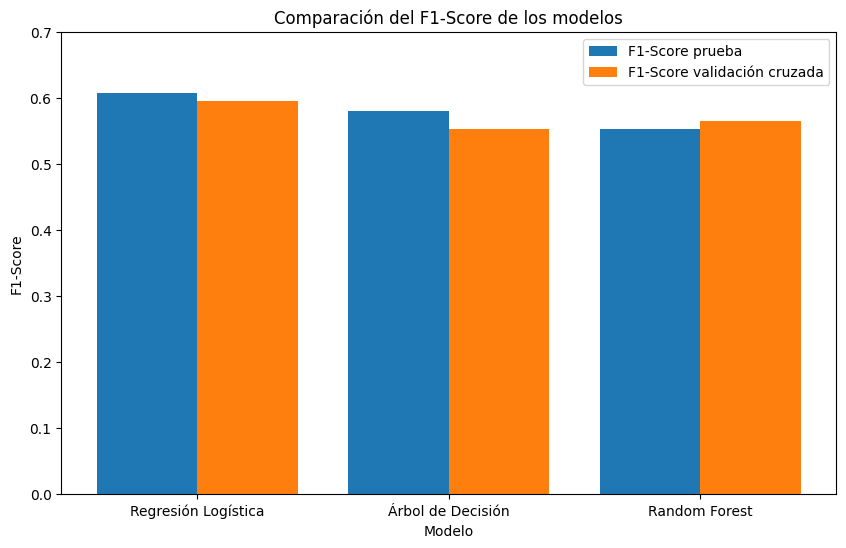

In [85]:
import matplotlib.pyplot as plt

modelos_grafico = tabla_comparativa["Modelo"]

plt.figure(figsize=(10, 6))

x = range(len(modelos_grafico))

plt.bar(
    [i - 0.2 for i in x],
    tabla_comparativa["F1-Score"],
    width=0.4,
    label="F1-Score prueba"
)

plt.bar(
    [i + 0.2 for i in x],
    tabla_comparativa["CV F1-Score"],
    width=0.4,
    label="F1-Score validación cruzada"
)

plt.xticks(x, modelos_grafico)
plt.ylabel("F1-Score")
plt.xlabel("Modelo")
plt.title("Comparación del F1-Score de los modelos")
plt.legend()
plt.ylim(0, 0.7)
plt.show()

interpretar los resultados

In [86]:
from sklearn.metrics import confusion_matrix
import pandas as pd

matriz_lr = confusion_matrix(y_test, y_pred_lr)
matriz_arbol = confusion_matrix(y_test, y_pred_arbol)
matriz_rf = confusion_matrix(y_test, y_pred_rf)

print("Matriz de confusión - Regresión Logística:")
print(matriz_lr)

print("\nMatriz de confusión - Árbol de Decisión:")
print(matriz_arbol)

print("\nMatriz de confusión - Random Forest:")
print(matriz_rf)

Matriz de confusión - Regresión Logística:
[[919 114]
 [161 213]]

Matriz de confusión - Árbol de Decisión:
[[877 156]
 [157 217]]

Matriz de confusión - Random Forest:
[[929 104]
 [191 183]]


gráfica visual de las matrices de confusión

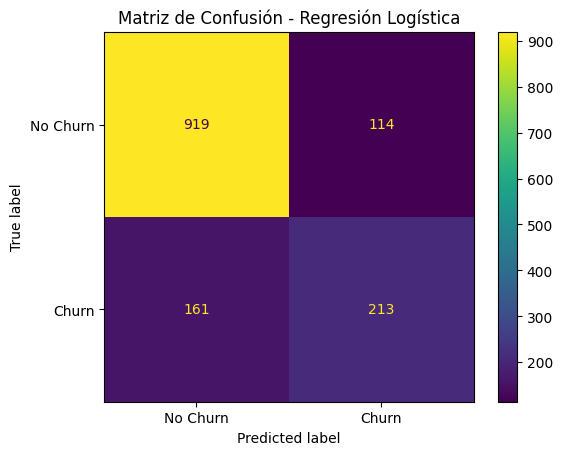

In [87]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_lr,
    display_labels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión - Regresión Logística")
plt.show()

correspondiente al Árbol de Decisión.

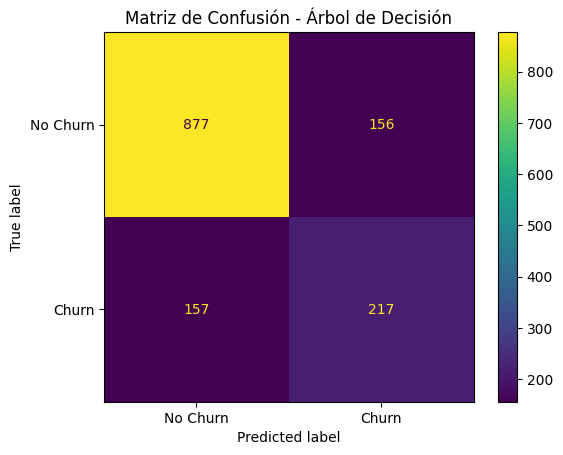

In [88]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_arbol,
    display_labels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión - Árbol de Decisión")
plt.show()

Random Forest.

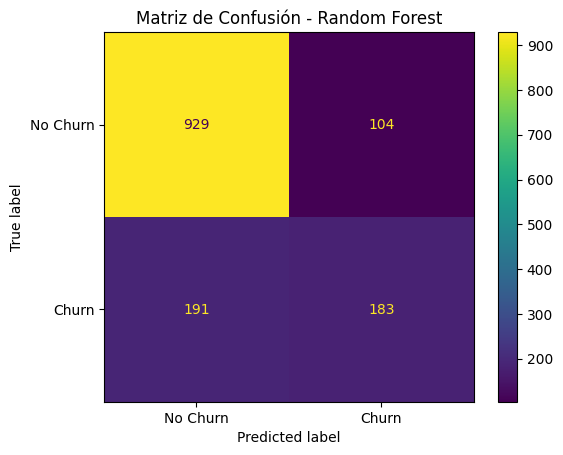

In [89]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_rf,
    display_labels=["No Churn", "Churn"]
)

plt.title("Matriz de Confusión - Random Forest")
plt.show()

interpretar y documentar los resultados de los modelos.

Paso siguiente: generar una tabla de interpretación

In [90]:
interpretacion = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "Verdaderos Negativos (TN)": [919, 877, 929],
    "Falsos Positivos (FP)": [114, 156, 104],
    "Falsos Negativos (FN)": [161, 157, 191],
    "Verdaderos Positivos (TP)": [213, 217, 183]
})

print(interpretacion)

                Modelo  Verdaderos Negativos (TN)  Falsos Positivos (FP)  \
0  Regresión Logística                        919                    114   
1    Árbol de Decisión                        877                    156   
2        Random Forest                        929                    104   

   Falsos Negativos (FN)  Verdaderos Positivos (TP)  
0                    161                        213  
1                    157                        217  
2                    191                        183  


interpretación automática de resultados

Ahora vamos a generar una tabla final con los resultados de prueba + validación cruzada, que será muy útil para la sección de Evaluación y validación.

In [91]:
tabla_final = tabla_comparativa.copy()

tabla_final["Diferencia F1"] = (
    tabla_final["F1-Score"] - tabla_final["CV F1-Score"]
)

print(tabla_final.round(4))

                Modelo  Accuracy  Precision  Recall  F1-Score  CV F1-Score  \
0  Regresión Logística    0.8045     0.6514  0.5695    0.6077       0.5957   
1    Árbol de Decisión    0.7775     0.5818  0.5802    0.5810       0.5538   
2        Random Forest    0.7903     0.6376  0.4893    0.5537       0.5658   

   Diferencia F1  
0         0.0120  
1         0.0272  
2        -0.0121  


gráfica de Accuracy, Precision, Recall y F1-Score para los tres modelos. Esto nos servirá como evidencia gráfica adicional de la comparación.

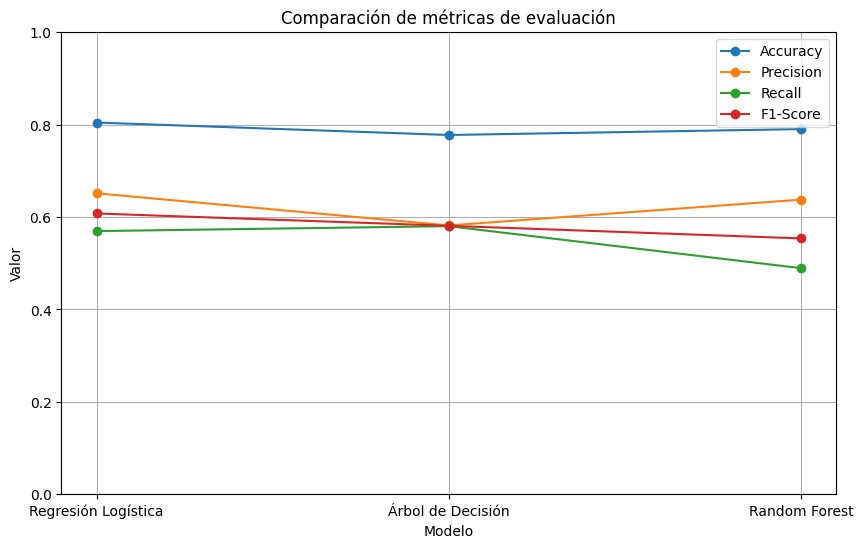

In [92]:
import matplotlib.pyplot as plt

metricas = ["Accuracy", "Precision", "Recall", "F1-Score"]

x = range(len(tabla_resultados["Modelo"]))

plt.figure(figsize=(10, 6))

for i, metrica in enumerate(metricas):
    plt.plot(
        x,
        tabla_resultados[metrica],
        marker="o",
        label=metrica
    )

plt.xticks(x, tabla_resultados["Modelo"])
plt.ylabel("Valor")
plt.xlabel("Modelo")
plt.title("Comparación de métricas de evaluación")
plt.legend()
plt.ylim(0, 1)
plt.grid(True)
plt.show()

tabla resumen completa

In [93]:
tabla_resumen = pd.DataFrame({
    "Modelo": [
        "Regresión Logística",
        "Árbol de Decisión",
        "Random Forest"
    ],
    "Accuracy": [0.8045, 0.7775, 0.7903],
    "Precision": [0.6514, 0.5818, 0.6376],
    "Recall": [0.5695, 0.5802, 0.4893],
    "F1-Score": [0.6077, 0.5810, 0.5537],
    "CV F1-Score": [0.5957, 0.5538, 0.5658],
    "TN": [919, 877, 929],
    "FP": [114, 156, 104],
    "FN": [161, 157, 191],
    "TP": [213, 217, 183]
})

print(tabla_resumen.round(4))

                Modelo  Accuracy  Precision  Recall  F1-Score  CV F1-Score  \
0  Regresión Logística    0.8045     0.6514  0.5695    0.6077       0.5957   
1    Árbol de Decisión    0.7775     0.5818  0.5802    0.5810       0.5538   
2        Random Forest    0.7903     0.6376  0.4893    0.5537       0.5658   

    TN   FP   FN   TP  
0  919  114  161  213  
1  877  156  157  217  
2  929  104  191  183  
